In [123]:
# import das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency

In [ ]:
# Carregar os dados
dados = pd.read_excel('tabelas_excel/planilha_modulo3.xlsx')
dados_licitcoes = pd.read_excel('tabelas_excel/licitacoes.xlsx')
dados2 = pd.read_excel('tabelas_excel/Planilha_Aula_parte2.xlsx')


## Módulo 2: Lendo e Entendendo Nossos Dados

- `head()`: exibe as 5 primeiras linhas da tabela
- `head(n)`: exibe ás n primeiras linhas
- `tail()`: exibe ás ultimas linhas da tabela
- `dados.shape`: mostra as dimensões da tabela -> (quantidade de linhas, quantidade de colunas)
- `len(dados)`: mostra quantos registros a tabela tem (linhas)
- `dados.columns`: exibe o nome das colunas que a tabela tem
- `dados.describe()`: gera um resumo estatístico das colunas numéricas 


In [125]:
dados.head()

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,DBA/Administrador de Banco de Dados,Júnior,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,11194.0
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,Outra Opção,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Menos de 1 ano,4695.0
2,2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 12.001/mês a R$ 16.000/mês,de 3 a 4 anos,Mais de 10 anos,14202.0
3,3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Setor Automotivo,Acima de 3.000,0.0,NaN,Cientista de Dados/Data Scientist,Sênior,de R$ 12.001/mês a R$ 16.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,15463.0
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0


In [126]:
dados.head(10) # 10 primeiras linhas

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,DBA/Administrador de Banco de Dados,Júnior,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,11194.0
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,Outra Opção,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Menos de 1 ano,4695.0
2,2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 12.001/mês a R$ 16.000/mês,de 3 a 4 anos,Mais de 10 anos,14202.0
3,3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Setor Automotivo,Acima de 3.000,0.0,NaN,Cientista de Dados/Data Scientist,Sênior,de R$ 12.001/mês a R$ 16.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,15463.0
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
6,6,zytlxsdgalh22cgrijvzytlxa49i8yzx,21.0,17-21,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Analista de BI/BI Analyst,Júnior,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Menos de 1 ano,4491.0
7,7,zyc0twzno2sm5or5ovoxzyc0twz0300d,31.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 6 a 10,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 2.001/mês a R$ 3.000/mês,Menos de 1 ano,Menos de 1 ano,2704.0
8,8,zy4o5dk6iuxpdwgzy4o58xvd6ykwohrj,33.0,30-34,Masculino,Branca,Não,NaN,NaN,True,...,Tecnologia/Fábrica de Software,Acima de 3.000,0.0,NaN,Analista de BI/BI Analyst,Sênior,de R$ 6.001/mês a R$ 8.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,7112.0
9,9,zxc3d314cn1c2ovmzxc34ha7nkw1na3j,NaN,55+,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,10822.0


In [127]:
dados.tail() # 5 ultimas linhas da tabela

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
4266,4266,01jnrn9f6va0menfhk2ztm01jnrn96bp,26.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Tecnologia/Fábrica de Software,Acima de 3.000,0.0,NaN,Analista de Dados/Data Analyst,Pleno,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,de 7 a 10 anos,4329.0
4267,4267,01dyfxam4u4bi29fem01dyfxaq9akvqp,30.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Área de Consultoria,de 51 a 100,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 3.001/mês a R$ 4.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,3758.0
4268,4268,00zw9ks9d40z4u00zz3d20iix65qpli3,29.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Setor Imobiliário/ Construção Civil,de 101 a 500,1.0,Gerente/Head,NaN,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,19607.0
4269,4269,00xu7yujd7s57emj00xu7y0c3njix3de,NaN,17-21,Masculino,Branca,Não,NaN,NaN,True,...,Indústria,de 1.001 a 3.000,0.0,NaN,Outra Opção,Júnior,Menos de R$ 1.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,989.0
4270,4270,00lb35llmdsidpa00lb35qcdysnzvhv7,24.0,22-24,Masculino,Branca,Não,NaN,NaN,True,...,Agronegócios,de 501 a 1.000,0.0,NaN,Analista de Dados/Data Analyst,Júnior,de R$ 3.001/mês a R$ 4.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,3079.0


In [128]:
print("Tamanho da tabela: (quantidade de linhas, quantidade de colunas) ->", dados.shape)
print("Quantidade de registros:", len(dados))

Tamanho da tabela: (quantidade de linhas, quantidade de colunas) -> (4271, 28)
Quantidade de registros: 4271


In [129]:
print("Colunas da tabela:", dados.columns)

Colunas da tabela: Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'NIVEL', 'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO'],
      dtype='str')


In [130]:
print("Informações sobre as colunas da tabela:", dados.info())

<class 'pandas.DataFrame'>
RangeIndex: 4271 entries, 0 to 4270
Data columns (total 28 columns):
 #   Column                                                                                                                     Non-Null Count  Dtype  
---  ------                                                                                                                     --------------  -----  
 0   Unnamed: 0                                                                                                                 4271 non-null   int64  
 1   ID                                                                                                                         4271 non-null   str    
 2   IDADE                                                                                                                      4197 non-null   float64
 3   FAIXA IDADE                                                                                                                4271 non-null   

In [131]:
dados.describe()

,Unnamed: 0,IDADE,MUDOU DE ESTADO?,GESTOR?,SALARIO
count,4271.000000,4197.000000,4171.000000,3694.000000,3694.000000
mean,2135.000000,31.169168,0.806281,0.193016,10969.266919
std,1233.075829,6.902803,0.395258,0.394719,19419.753189
min,0.000000,18.000000,0.000000,0.000000,35.000000
25%,1067.500000,26.000000,1.000000,0.000000,4269.500000
50%,2135.000000,30.000000,1.000000,0.000000,7625.500000
75%,3202.500000,35.000000,1.000000,0.000000,12778.500000
max,4270.000000,54.000000,1.000000,1.000000,485191.000000


### Repetindo Análise Feita no EXCEL

**Técnicas de Filtragem e Análise Utilizadas**
- `dados['COLUNA']`: acessa uma coluna específica
- `dados[dados['COLUNA'] == 'valor']`: filtra registros com valor específico
- `dados[dados['COLUNA'] != 'valor']`: filtra registros que NÃO contêm um valor
- `dados[dados['COLUNA'].str.contains('texto', na=False)]`: filtra registros que contêm um texto
- `dados[dados['COLUNA'] >= valor]`: filtra por valores numéricos (>, <, >=, <=)
- `dados[(condicao1) & (condicao2)]`: combina múltiplas condições com operador lógico
- `dados['COLUNA'].nunique()`: conta quantos valores únicos existem em uma coluna
- `dados['COLUNA'].value_counts()`: conta a frequência de cada valor
- `dados.groupby('COLUNA')['OUTRA_COLUNA'].nunique()`: agrupa dados e conta valores únicos
- `pd.pivot_table()`: cria tabelas dinâmicas/resumidas dos dados

**Análises Realizadas**
- Quantas pessoas são do gênero feminino?
- Quantas pessoas NÃO são do gênero masculino?
- Quais registros contêm a palavra "não" no campo de gênero?
- Quantas pessoas têm idade maior ou igual a 30 anos?
- Quantas mulheres têm mais de 30 anos?
- Quantos estados únicos existem (localidades)?
- Qual é a distribuição de áreas de formação?
- Como se distribui a cor/raça/etnia?
- Quais mulheres de etnia Amarela têm menos de 40 anos?
- Qual é o nível educacional de pessoas acima de 30 anos?
- Qual é o nível educacional de mulheres acima de 30 anos?
- Qual é a relação entre gênero e posição de gestor?

In [132]:
dados['GENERO']

0       Masculino
1       Masculino
2       Masculino
3       Masculino
4        Feminino
          ...    
4266    Masculino
4267     Feminino
4268    Masculino
4269    Masculino
4270    Masculino
Name: GENERO, Length: 4271, dtype: str

In [133]:
# filtrando para trazer apenas os registros que preencheram a coluna genero como feminino
dados[dados['GENERO'] == 'Feminino']

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
7,7,zyc0twzno2sm5or5ovoxzyc0twz0300d,31.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 6 a 10,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 2.001/mês a R$ 3.000/mês,Menos de 1 ano,Menos de 1 ano,2704.0
9,9,zxc3d314cn1c2ovmzxc34ha7nkw1na3j,NaN,55+,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,10822.0
10,10,zwy34gktg0tfjq2ttjvazwy34gg3g49i,25.0,25-29,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Varejo,de 101 a 500,0.0,NaN,Analista de BI/BI Analyst,Júnior,de R$ 3.001/mês a R$ 4.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,3450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4248,4248,070o4zayoboztox764qu070o4zafbqrd,27.0,25-29,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,de 101 a 500,0.0,NaN,Cientista de Dados/Data Scientist,Pleno,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,4781.0
4251,4251,068hhicrqggu068huq0l2ab3g7liagy8,34.0,30-34,Feminino,Preta,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,de 1.001 a 3.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 4.001/mês a R$ 6.000/mês,Menos de 1 ano,Menos de 1 ano,5673.0
4258,4258,03zjgijmnwv9qrlzbr03zjgij1eae1hw,25.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Senioridade das vagas recebidas em relação à s...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4259,4259,03n2lq8st9zobnowu3w03n2lqi0flz2w,28.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...","Relação com outros membros da empresa, em mome...",True,...,Finanças ou Bancos,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 20.001/mês a R$ 25.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,24963.0


In [134]:
# filtrando para trazer apenas os registros que não preencheram a coluna genero como masculino
dados[dados['GENERO'] != 'Masculino']

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
7,7,zyc0twzno2sm5or5ovoxzyc0twz0300d,31.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 6 a 10,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 2.001/mês a R$ 3.000/mês,Menos de 1 ano,Menos de 1 ano,2704.0
9,9,zxc3d314cn1c2ovmzxc34ha7nkw1na3j,NaN,55+,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,10822.0
10,10,zwy34gktg0tfjq2ttjvazwy34gg3g49i,25.0,25-29,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Varejo,de 101 a 500,0.0,NaN,Analista de BI/BI Analyst,Júnior,de R$ 3.001/mês a R$ 4.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,3450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4248,4248,070o4zayoboztox764qu070o4zafbqrd,27.0,25-29,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,de 101 a 500,0.0,NaN,Cientista de Dados/Data Scientist,Pleno,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,4781.0
4251,4251,068hhicrqggu068huq0l2ab3g7liagy8,34.0,30-34,Feminino,Preta,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,de 1.001 a 3.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 4.001/mês a R$ 6.000/mês,Menos de 1 ano,Menos de 1 ano,5673.0
4258,4258,03zjgijmnwv9qrlzbr03zjgij1eae1hw,25.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Senioridade das vagas recebidas em relação à s...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4259,4259,03n2lq8st9zobnowu3w03n2lqi0flz2w,28.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...","Relação com outros membros da empresa, em mome...",True,...,Finanças ou Bancos,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 20.001/mês a R$ 25.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,24963.0


In [135]:
dados[dados['GENERO'].str.contains('não', na=False)]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
562,562,vhuw8xnpbmj6oh20xovhuwcbdl4a12ni,29.0,25-29,Prefiro não informar,Parda,Não,"Sim, acredito que a minha a experiência profis...",Atenção dada pelas pessoas diante das minhas o...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1528,1528,n2ktdn33istvlu1ha4v3kn2ktdn1rsp1,NaN,55+,Prefiro não informar,Indígena,Prefiro não informar,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 51 a 100,0.0,NaN,Analista de Suporte/Analista Técnico,Júnior,Menos de R$ 1.000/mês,Menos de 1 ano,Menos de 1 ano,826.0
1913,1913,k3as6jdh3w4jf4ztsw4kpkk3as6jdy19,30.0,30-34,Prefiro não informar,Prefiro não informar,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Outra Opção,de 101 a 500,0.0,NaN,Analista de Dados/Data Analyst,Pleno,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,de 3 a 4 anos,11476.0
1925,1925,jzppdwep2kpisqjjzppdh304v83cj7eu,NaN,17-21,Prefiro não informar,Prefiro não informar,Prefiro não informar,"Sim, acredito que minha experiência profission...",Quantidade de oportunidades de emprego/vagas r...,False,...,Setor Farmaceutico,de 1 a 5,0.0,NaN,Outra Opção,Júnior,de R$ 2.001/mês a R$ 3.000/mês,de 1 a 2 anos,Menos de 1 ano,2294.0
2554,2554,f5l206z0hr9uh3nz2iiff5l206c0g10o,20.0,17-21,Prefiro não informar,Prefiro não informar,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,Cientista de Dados/Data Scientist,Júnior,de R$ 1.001/mês a R$ 2.000/mês,de 1 a 2 anos,de 1 a 2 anos,1339.0
3090,3090,a6ugmsw7s8hu5aa6uglio5apj74fam9o,26.0,25-29,Prefiro não informar,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,de 101 a 500,1.0,Team Leader/Tech Leader,NaN,NaN,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,11545.0
3357,3357,7q0icczxn0l3a894cbx7q0icczjyud0n,29.0,25-29,Prefiro não informar,Preta,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 1.001 a 3.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Júnior,de R$ 6.001/mês a R$ 8.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,6345.0
3493,3493,6m8haop6lxnaizpwij6m8haopiax98jg,25.0,25-29,Prefiro não informar,Branca,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Analista de Dados/Data Analyst,Pleno,de R$ 3.001/mês a R$ 4.000/mês,de 3 a 4 anos,Menos de 1 ano,3900.0
3610,3610,5mloglozmr0r715mntaxbt6xy8b5olmb,30.0,30-34,Prefiro não informar,Branca,Não,"Sim, acredito que a minha a experiência profis...",Velocidade de progressão de carreira,True,...,Tecnologia/Fábrica de Software,de 101 a 500,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Sênior,de R$ 8.001/mês a R$ 12.000/mês,de 3 a 4 anos,Não tive experiência na área de TI/Engenharia ...,10174.0
4171,4171,0rksyxnqhn13nwytwi6y0rkssx6jmodf,26.0,25-29,Prefiro não informar,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Outra Opção,de 1.001 a 3.000,0.0,NaN,Analista de Dados/Data Analyst,Pleno,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,Menos de 1 ano,10517.0


In [136]:
# filtrando registros que possuem idade maior ou igual a 30
dados[dados['IDADE'] >= 30 ]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,DBA/Administrador de Banco de Dados,Júnior,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,11194.0
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,Outra Opção,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Menos de 1 ano,4695.0
2,2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 12.001/mês a R$ 16.000/mês,de 3 a 4 anos,Mais de 10 anos,14202.0
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4260,4260,03atvow8404tatt2iixjds03atvownkz,36.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4261,4261,02xomoejng6c9152kde02xomww412qpg,33.0,30-34,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4262,4262,02vlm03c29g3fcys8tj06102vlm0983h,31.0,30-34,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 501 a 1.000,1.0,Team Leader/Tech Leader,NaN,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 3 a 4 anos,de 3 a 4 anos,18402.0
4264,4264,028mfisr3mqazkn5n6swe028mt55nqzq,37.0,35-39,Masculino,Branca,Não,NaN,NaN,True,...,Tecnologia/Fábrica de Software,de 51 a 100,1.0,Gerente/Head,NaN,NaN,de R$ 20.001/mês a R$ 25.000/mês,de 3 a 4 anos,Mais de 10 anos,24543.0


In [137]:
# filtrando registros que possuem idade maior que 30 e são do genero feminino
dados[(dados['IDADE'] > 30) & (dados['GENERO'] == 'Feminino')]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
7,7,zyc0twzno2sm5or5ovoxzyc0twz0300d,31.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 6 a 10,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 2.001/mês a R$ 3.000/mês,Menos de 1 ano,Menos de 1 ano,2704.0
14,14,zwez49k0jhdvfkfst4zwef137uuf4ivy,35.0,35-39,Feminino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Atenção dada pelas pessoas diante das minhas o...,True,...,Varejo,Acima de 3.000,0.0,NaN,Analista de Negócios/Business Analyst,Pleno,de R$ 6.001/mês a R$ 8.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,7416.0
23,23,zuqfcwtl9unfc5ezuqfcwm8coytsp5ap,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 501 a 1.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Sênior,de R$ 12.001/mês a R$ 16.000/mês,Mais de 10 anos,de 5 a 6 anos,13418.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4214,4214,0gprow0ownrbfneftxf0gprow4kyrqdy,41.0,40-44,Feminino,Branca,Prefiro não informar,"Sim, acredito que a minha a experiência profis...","Oportunidades de progressão de carreira, Veloc...",True,...,Seguros ou Previdência,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 8.001/mês a R$ 12.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,11452.0
4221,4221,0fgi5bnb0u9b0fgc0jmqlbnvtu12b76d,34.0,30-34,Feminino,Outra,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Área de Consultoria,de 51 a 100,0.0,NaN,Outra Opção,Júnior,de R$ 4.001/mês a R$ 6.000/mês,Menos de 1 ano,Menos de 1 ano,5687.0
4240,4240,0a5xgxb1ljmuqn0un8a10a5xg4eufs2l,37.0,35-39,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,True,...,Finanças ou Bancos,de 51 a 100,0.0,NaN,Analista de BI/BI Analyst,Júnior,de R$ 1.001/mês a R$ 2.000/mês,de 1 a 2 anos,Menos de 1 ano,1182.0
4247,4247,07qzabp4ujpe4oz81udmb07qzabp4h0t,34.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor de Energia,de 11 a 50,0.0,NaN,Cientista de Dados/Data Scientist,Júnior,de R$ 4.001/mês a R$ 6.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,5925.0


In [138]:
# nunique() - é usado para calcular o número de valores únicos (distintos) em uma coluna
dados['ESTADO ONDE MORA'].nunique()

22

In [139]:
dados['ÁREA DE FORMAÇÃO'].value_counts()

ÁREA DE FORMAÇÃO
Computação / Engenharia de Software / Sistemas de Informação/ TI          1543
Outras Engenharias                                                         941
Economia/ Administração / Contabilidade / Finanças/ Negócios               641
Estatística/ Matemática / Matemática Computacional/ Ciências Atuariais     405
Outra opção                                                                200
Marketing / Publicidade / Comunicação / Jornalismo                         122
Química / Física                                                           112
Ciências Biológicas/ Farmácia/ Medicina/ Área da Saúde                     111
Ciências Sociais                                                            74
Name: count, dtype: int64

In [140]:
dados['COR/RACA/ETNIA'].value_counts()

COR/RACA/ETNIA
Branca                  2744
Parda                   1054
Preta                    291
Amarela                  128
Prefiro não informar      26
Outra                     17
Indígena                  11
Name: count, dtype: int64

In [141]:
dados[dados['COR/RACA/ETNIA'] == 'Amarela']

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
13,13,zwh83jpy6x40b95xigsr2zwh83jpflu3,24.0,22-24,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Analista de Negócios/Business Analyst,Júnior,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Menos de 1 ano,5296.0
85,85,zfeuk2m9jozahicujlla8zfeuk2g7apj,29.0,25-29,Feminino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,97,zbukfwxvpwlk6loglm0zbukfwx6bvyb6,40.0,40-44,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Varejo,Acima de 3.000,0.0,NaN,Analista de BI/BI Analyst,Sênior,de R$ 8.001/mês a R$ 12.000/mês,de 4 a 6 anos,Mais de 10 anos,11388.0
107,107,z9toybzbja7n6xjjbz9f8hmofrry69tg,44.0,40-44,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Indústria,Acima de 3.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Sênior,de R$ 12.001/mês a R$ 16.000/mês,Mais de 10 anos,Mais de 10 anos,14500.0
159,159,ytrnz3zyvn791t3dum1ytrnz3zp22tmk,37.0,35-39,Feminino,Amarela,Não,"Sim, acredito que a minha a experiência profis...","Oportunidades de progressão de carreira, Aprov...",True,...,Tecnologia/Fábrica de Software,de 101 a 500,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,10628.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4176,4176,0qpa64gqpieg60xpygnajt70qpa64g1a,27.0,25-29,Feminino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4207,4207,0ibb8fj9qrwpswfqiil0ibb89e3e4hz3,30.0,30-34,Feminino,Amarela,Não,"Sim, acredito que a minha a experiência profis...","Oportunidades de progressão de carreira, Veloc...",True,...,Área de Consultoria,de 501 a 1.000,0.0,NaN,Cientista de Dados/Data Scientist,Sênior,de R$ 16.001/mês a R$ 20.000/mês,de 4 a 6 anos,de 5 a 6 anos,16298.0
4210,4210,0hbwm1d1wz739r40hbwm1df6ky5kn4ap,43.0,40-44,Feminino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Sênior,de R$ 6.001/mês a R$ 8.000/mês,de 1 a 2 anos,Mais de 10 anos,7131.0
4257,4257,043snvbsxn3fuyfe043j5comuyu8g6ba,46.0,45-49,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,Acima de 3.000,1.0,Gerente/Head,NaN,NaN,Acima de R$ 40.001/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,62001.0


In [142]:
dados[(dados['IDADE'] < 40) & (dados['COR/RACA/ETNIA'] == 'Amarela')]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
13,13,zwh83jpy6x40b95xigsr2zwh83jpflu3,24.0,22-24,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Analista de Negócios/Business Analyst,Júnior,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Menos de 1 ano,5296.0
85,85,zfeuk2m9jozahicujlla8zfeuk2g7apj,29.0,25-29,Feminino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
159,159,ytrnz3zyvn791t3dum1ytrnz3zp22tmk,37.0,35-39,Feminino,Amarela,Não,"Sim, acredito que a minha a experiência profis...","Oportunidades de progressão de carreira, Aprov...",True,...,Tecnologia/Fábrica de Software,de 101 a 500,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,10628.0
170,170,yri3z491ejizlpj9ylu2k3jyri3z4915,34.0,30-34,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Varejo,Acima de 3.000,1.0,Gerente/Head,NaN,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 3 a 4 anos,Não tive experiência na área de TI/Engenharia ...,16650.0
195,195,yjbpxmkqz5yidh5oszyjbpxmkgcb1zd9,32.0,30-34,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3947,3947,2tnsh0gxdu3aq4z2d2tnsh0hk15brx7q,31.0,30-34,Feminino,Amarela,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,False,...,Tecnologia/Fábrica de Software,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 25.001/mês a R$ 30.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,29408.0
4058,4058,1t3ndwx8j50k0bz1t3ndwxdpwyg17c2k,27.0,25-29,Feminino,Amarela,Não,"Sim, acredito que a minha a experiência profis...",Nível de cobrança no trabalho / Stress no trab...,True,...,Tecnologia/Fábrica de Software,Acima de 3.000,0.0,NaN,Cientista de Dados/Data Scientist,Sênior,de R$ 12.001/mês a R$ 16.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,14175.0
4176,4176,0qpa64gqpieg60xpygnajt70qpa64g1a,27.0,25-29,Feminino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4207,4207,0ibb8fj9qrwpswfqiil0ibb89e3e4hz3,30.0,30-34,Feminino,Amarela,Não,"Sim, acredito que a minha a experiência profis...","Oportunidades de progressão de carreira, Veloc...",True,...,Área de Consultoria,de 501 a 1.000,0.0,NaN,Cientista de Dados/Data Scientist,Sênior,de R$ 16.001/mês a R$ 20.000/mês,de 4 a 6 anos,de 5 a 6 anos,16298.0


In [143]:
dados.groupby('GENERO', dropna=False)['ID'].nunique()

GENERO
Feminino                1055
Masculino               3194
Prefiro não informar      12
NaN                        9
Name: ID, dtype: int64

In [144]:
dados['GENERO'].value_counts(dropna=False)

GENERO
Masculino               3194
Feminino                1056
Prefiro não informar      12
NaN                        9
Name: count, dtype: int64

In [145]:
dados[dados['IDADE'] > 30]['NIVEL'].value_counts()

NIVEL
Sênior    525
Pleno     408
Júnior    274
Name: count, dtype: int64

In [146]:
dados[(dados['IDADE'] > 30) & (dados['GENERO'] == 'Feminino')]['NIVEL'].value_counts()

NIVEL
Pleno     117
Sênior    114
Júnior     96
Name: count, dtype: int64

In [147]:
pd.pivot_table(dados, values=['ID'], index=['GENERO'], columns=['GESTOR?'], aggfunc='count')

ID     
GESTOR?                0.0  1.0
GENERO                         
Feminino               754  132
Masculino             2212  578
Prefiro não informar     9    2

## Módulo 3: Estatística

**Média:** Representa o valor central dos dados. É calculada pela soma de todos os valores e divisão pela quantidade de valores.

- A função np.mean() é utilizada para calcular a média em listas do NumPy.
- A função dados["IDADE"].mean() calcula a média da coluna "IDADE" no Pandas.

Podemos calcular também a média ponderada, em que cada valor tem um peso diferente. Por exemplo, vamos imaginar que estamos fazendo uma votação para definir o preço de um produto em uma empresa, mas os votos dos diretores da empresa têm um peso maior. Então para isso temos uma coluna com os pesos dos votos e outra com o preço. O cálculo da média ponderada fica assim:

- media_ponderada = (df[Preco] * df['Pesos']).sum() / df['Pesos'].sum()

**Mediana:** Valor central dos dados ordenados. Menos afetada por valores extremos ("outliers").

- A função np.median() calcula a mediana em listas do NumPy.
- A função dados["IDADE"].median() calcula a mediana da coluna "IDADE" no Pandas.

**Moda:** Valor que aparece mais frequentemente nos dados.

- A função dados["IDADE"].mode() calcula a moda da coluna "IDADE" no Pandas.

**Desvio Padrão:** Mede a dispersão dos dados em relação à média.

- A função dados["IDADE"].std() calcula o desvio padrão da coluna "IDADE" no Pandas.

**Min e Max:** Retornam o menor e o maior valor da coluna, respectivamente.

- A função dados["IDADE"].min() retorna o valor mínimo da coluna "IDADE" no Pandas.
- A função dados["IDADE"].max() retorna o valor máximo da coluna "IDADE" no Pandas.

In [148]:
lista_idade = [26, 30, 32, 22, 26, 35, 40, 20, 43, 31, 23]
print("Média de idades:", sum(lista_idade) / len(lista_idade))

Média de idades: 29.818181818181817


In [149]:
media = np.mean(lista_idade)
print("Média também:", media)
lista_idade.sort()
print(lista_idade)
print(len(lista_idade))
print("Mediana da lista de idade:", lista_idade[6])

Média também: 29.818181818181817
[20, 22, 23, 26, 26, 30, 31, 32, 35, 40, 43]
11
Mediana da lista de idade: 31


In [150]:
print('media =', dados['IDADE'].mean()) # a função mean() tem na biblioteca do pandas também
print('mediana =', dados['IDADE'].median())
print('media idades =', dados['IDADE'].mode()) #trazer a moda - número que mais se repete
print('desvio padrão coluna idade =', dados['IDADE'].std()) # calculo do desvio padrão
print('idade minina =', dados['IDADE'].min())
print('idade maxima =', dados['IDADE'].max())
print('media de idade do genero feminino =', dados[dados['GENERO'] == 'Feminino']['IDADE'].mean())
print('media de idade do genero masculino =', dados[dados['GENERO'] == 'Masculino']['IDADE'].mean())
print('media de salario do genero feminino =', dados[dados['GENERO'] == 'Feminino']['SALARIO'].mean())
print('media de salario do genero masculino =',dados[dados['GENERO'] == 'Masculino']['SALARIO'].mean())

media = 31.169168453657374
mediana = 30.0
media idades = 0    27.0
Name: IDADE, dtype: float64
desvio padrão coluna idade = 6.902802832143122
idade minina = 18.0
idade maxima = 54.0
media de idade do genero feminino = 31.318051575931232
media de idade do genero masculino = 31.147876077930373
media de salario do genero feminino = 8673.22460496614
media de salario do genero masculino = 11724.552688172043


### Tratando valores faltantes

Os dados nulos podem ter sido ocasionados por vários motivos: erro no preenchimento de dados, realmente falta da informação, apagamento de informações. Da mesma forma, não há um único método para tratar valores nulos. Podemos:

- **Deletar** todas as linhas com valores faltantes. É simples, mas pode resultar na perda de muitos dados, especialmente se houver muitos valores nulos.
- **Substituir** os valores faltantes pela média, ou mediana, ou moda para variáveis categóricas, ou algum valor padrão. Contudo, essa prática pode ignorar a relação entre variáveis.

Nessa aula vimos que temos 3 colunas com valores nulos na nossa tabela: GENERO, IDADE e SALÁRIO. 

- A coluna "GENERO" tem 9 valores nulos e nesse caso decidimos preencher com um valor padrão já usado na tabela: "Prefiro não informar", para isso usamos a função fillna() que pega os nulos e substitui pelo valor passado.

In [151]:
# COLUNA GENERO: 
dados.groupby('GENERO', dropna=False)['ID'].nunique() 

# preencher os valores NaN com prefiro não informar
dados['GENERO'] = dados['GENERO'].fillna("Prefiro não informar")

Para a coluna "IDADE", vimos que temos uma coluna que podemos usar de auxílio para preencher os nulos. Então substituímos os valores nulos pela média das idades na faixa etária correspondente. Por exemplo, a média da faixa 17-21 é usada para preencher esses valores nulos.

In [152]:
# COLUNA IDADE
dados['IDADE'].isnull().value_counts()

# verificar se as pessoas que não preencheram a idade preencheram a coluna de faixa de idade
dados[dados['IDADE'].isnull()]['FAIXA IDADE'].value_counts()
# na segunda imagem vemos que todas as pessoas que não preencheram a coluna idade preencheram a coluna faixa idade

# substituindo os valores nulos que a faixa de idade é == 17-21 com a média
media_17_21 = dados[dados['FAIXA IDADE'] == '17-21']['IDADE'].mean() # output: 20.20
dados.loc[(dados['FAIXA IDADE'] == '17-21') & (dados['IDADE'].isnull()), 'IDADE'] = media_17_21 

# substituindo os valores nulos que a faixa de idade é == 55+ com a média
dados[dados['FAIXA IDADE'] == '55+']['IDADE'].mean() # output: NaN
dados[dados['FAIXA IDADE'] == '55+']['IDADE'] 

# vemos que todas as pessoas que marcaram faixa de idade maior que 55 não preencheram o campo idade
# decidimos utilizar a media geral das idades para preecher esses valores nulos
media_geral = dados['IDADE'].mean() # 31.15
dados.loc[(dados['FAIXA IDADE'] == '55+') & (dados['IDADE'].isnull()), 'IDADE'] = media_geral

In [153]:
dados['IDADE'].isnull().value_counts() # false significa que todos os registros possuem esse campo preenchido

IDADE
False    4271
Name: count, dtype: int64

In [154]:
dados['FAIXA IDADE'].value_counts()

FAIXA IDADE
25-29    1398
30-34    1095
35-39     598
22-24     449
40-44     277
17-21     152
45-49     145
50-54      89
55+        68
Name: count, dtype: int64

Para a coluna "SALARIO", com 577 valores nulos e sem informações na coluna de Faixa salarial, usamos a mediana para preencher, pois ela é menos afetada por valores discrepantes.

In [155]:
# COLUNA SALARIO
# identificamos que as pessoas que não preencheram salario também não preencharam o campo de faixa salarial
print("Verificando se os dados nulos em salario possuem faixa salarial preenchido", dados[dados['SALARIO'].isnull()]['FAIXA SALARIAL'].value_counts())

mediana_salario = dados['SALARIO'].median() #output: 7625.5
print(mediana_salario)

dados.loc[dados['SALARIO'].isnull(), 'SALARIO'] = mediana_salario


Verificando se os dados nulos em salario possuem faixa salarial preenchido Series([], Name: count, dtype: int64)
7625.5


#### Tabela dados_licitações

Identificamos que a coluna Data Abertura possui valores nulos.

In [156]:
dados_licitcoes.info()

<class 'pandas.DataFrame'>
RangeIndex: 15336 entries, 0 to 15335
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Número Licitação          15336 non-null  int64         
 1   Código UG                 15336 non-null  int64         
 2   Nome UG                   15336 non-null  str           
 3   Código Modalidade Compra  15336 non-null  int64         
 4   Modalidade Compra         15336 non-null  str           
 5   Número Processo           15336 non-null  object        
 6   Objeto                    15336 non-null  str           
 7   Situação Licitação        15336 non-null  str           
 8   Código Órgão Superior     15336 non-null  int64         
 9   Nome Órgão Superior       15336 non-null  str           
 10  Código Órgão              15336 non-null  int64         
 11  Nome Órgão                15336 non-null  str           
 12  UF                        153

Decidimos colocar uma data inexistente para esses valores nulo - 00/00/0000

In [157]:
dados_licitcoes['Data Abertura'] = dados_licitcoes['Data Abertura'].fillna('00/00/0000')

In [158]:
dados_licitcoes.info()

<class 'pandas.DataFrame'>
RangeIndex: 15336 entries, 0 to 15335
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Número Licitação          15336 non-null  int64         
 1   Código UG                 15336 non-null  int64         
 2   Nome UG                   15336 non-null  str           
 3   Código Modalidade Compra  15336 non-null  int64         
 4   Modalidade Compra         15336 non-null  str           
 5   Número Processo           15336 non-null  object        
 6   Objeto                    15336 non-null  str           
 7   Situação Licitação        15336 non-null  str           
 8   Código Órgão Superior     15336 non-null  int64         
 9   Nome Órgão Superior       15336 non-null  str           
 10  Código Órgão              15336 non-null  int64         
 11  Nome Órgão                15336 non-null  str           
 12  UF                        153

### Tratando valores discrepantes (outliers)

In [159]:
print("Média da tabela de idades sem valor discrepante:", np.mean(lista_idade))

# adicionando um valor discrepante (400) para ver como ela interfere na média
lista_idade = [26, 30, 32, 22, 26, 35, 400, 20, 43, 31, 23]
print(np.mean(lista_idade)) 

Média da tabela de idades sem valor discrepante: 29.818181818181817
62.54545454545455


**Como identificar outliers?** um dos metodos estatísticos que podemos utilizar é a regra do desvio padrão, onde quanto mais próximo de zero, quer dizer que nossos dados estão mais homogêneos.
- Um desvio padrão = 106 significa que a chance de termos um outlier nos nossos dados é grande.

In [160]:
# verificando o desvio padrão da lista acima:
print(np.std(lista_idade))

106.89532997398872


**Como confirmar se há um outlier?**
- Abaixo calculamos o limite superior, que significa que acima do valor 383 é tudo outlier.

In [161]:
desvio = np.std(lista_idade) # output: 106.89
media = np.mean(lista_idade) # output: 62

# utilizando a média do desvio padrão:
print(media + 3 * desvio) # output: 383

383.2314444674207


Abaixo calculamos o limite inferior, que significa que abaixo do valor -258 é tudo outlier.
- Observação: É importante entender o contexto para saber se esses dois limites fazem sentido ou não.

In [162]:
desvio = np.std(lista_idade) # output: 106.89
media = np.mean(lista_idade) # output: 62

# utilizando a média do desvio padrão:
print(media - 3 * desvio) # output: -258

-258.1405353765116


Outra forma é utilizando a regra dos quartis, onde a gente divide o dado em quatro partes, usando três
valores

{'whiskers': [<matplotlib.lines.Line2D at 0x11a3925d0>,
 'caps': [<matplotlib.lines.Line2D at 0x11a392210>,
 'boxes': [<matplotlib.lines.Line2D at 0x11a392710>],
 'medians': [<matplotlib.lines.Line2D at 0x11a392490>],
 'fliers': [<matplotlib.lines.Line2D at 0x11a3920d0>],
 'means': []}

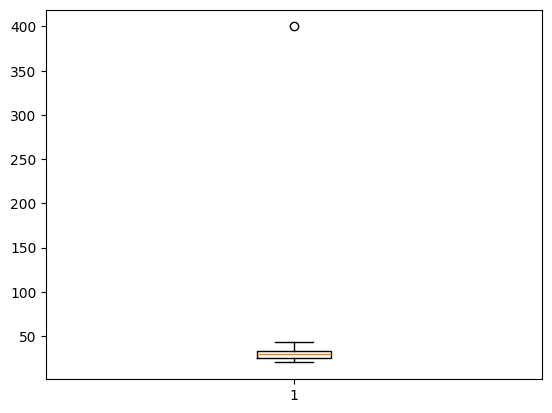

In [163]:
plt.boxplot(lista_idade)

Esse gráfico é um boxplot da lista de idades 

**Como interpretar o boxplot**

- **A caixa (retângulo)** representa onde está a “parte central” dos dados: do **1º quartil (Q1)** ao **3º quartil (Q3)**.
- **A linha dentro da caixa** é a **mediana** (o “valor do meio” quando você ordena a lista).
- **Os “bigodes”** (linhas que saem da caixa para cima e para baixo) mostram até onde vão os valores considerados “normais” (sem serem discrepantes),.
- **Pontos isolados fora dos bigodes** são **outliers**.
- Quase todos os valores da lista estão concentrados ali embaixo, na faixa **aproximadamente entre 20 e 43** (por isso a caixa aparece “baixinha” perto do eixo inferior).
- Existe um ponto bem alto, perto de **400**, que aparece **separado**: esse é o **outlier** (o valor discrepante que você adicionou: 400).
- Por causa desse 400, o gráfico “estica” a escala do eixo Y até 400, e isso faz a caixa parecer ainda mais “achatada” perto de zero.

O boxplot é ótimo justamente para isso: visualizar rapidamente a dispersão e identificar outliers.

Vemos que nessa coluna temos vários pontos fora da caixa, salários de 400 mil, 500 mil, etc

{'whiskers': [<matplotlib.lines.Line2D at 0x11adf9450>,
 'caps': [<matplotlib.lines.Line2D at 0x11adf96d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x11adf9310>],
 'medians': [<matplotlib.lines.Line2D at 0x11adf9950>],
 'fliers': [<matplotlib.lines.Line2D at 0x11adf9bd0>],
 'means': []}

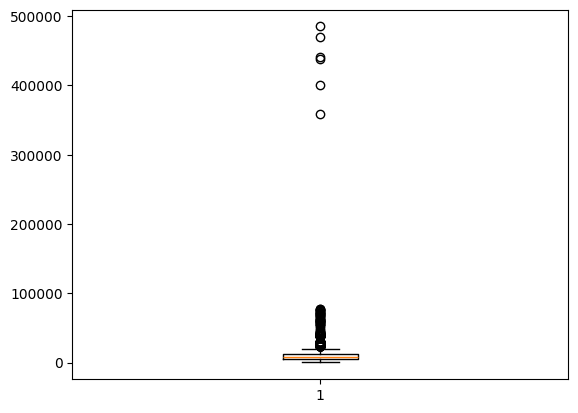

In [164]:
# verificando se há valores discrepantes na coluna de salário
plt.boxplot(dados['SALARIO'])

**Explicação dessa parte do código**

- **Q1 (1º quartil)**: é o valor abaixo do qual estão **25%** dos salários. Aqui deu **4751.51**.
- **Q3 (3º quartil)**: é o valor abaixo do qual estão **75%** dos salários. Aqui deu **11794.5**.
- **IQR (intervalo interquartil)**: é a distância entre Q3 e Q1 (**IQR = Q3 - Q1**). Ele mostra a “largura” do **meio** dos dados (os **50% salários centrais**). Aqui deu **7043.0**.
- **Limite superior**: **Q3 + 1.5 * IQR**. Acima desse valor, o salário é considerado **muito alto** e pode ser um **outlier**. Aqui deu **22359**.
- **Limite inferior**: **Q1 - 1.5 * IQR**. Abaixo desse valor, o salário é considerado **muito baixo** e pode ser um **outlier**. Aqui deu **-5813** (em salário, às vezes aparece negativo e não faz muito sentido na prática, mas a regra estatística é essa).

**Como interpretar isso na prática**

- Como **não existe salário negativo**, dá pra “ajustar” o limite inferior para no mínimo **0**: **max(lim_inferior, 0)**. Assim você evita considerar valores negativos como parte da regra.
- O valor **22359** (limite superior) quer dizer: “acima disso, vale investigar”, mas **não significa automaticamente** que todo salário acima de 22k é outlier.
- Por isso a aula olha a coluna **FAIXA SALARIAL** com `value_counts()`: pra entender a distribuição real. Se existem faixas como **25–30k** e **30–40k** com várias pessoas, esses salários podem ser **altos, mas plausíveis**.
- Já salários muito fora do padrão (ex.: **300k, 400k, 500k**), que aparecem isolados no boxplot, têm mais cara de **fora do contexto** (ou erro de dado) e aí sim podem ser tratados como outliers.

In [165]:
# trazendo os valores dos quartis. Q1 e Q3
Q1 = dados['SALARIO'].quantile(0.25) # 1/4 seria 0.25 
Q1 # output 4751.51

Q3 = dados['SALARIO'].quantile(0.75) # 3/4 seria 0.75 
Q3 # output 11794.5

# interquatil: valor que entre o Q1 e Q3
IQR = Q3-Q1
IQR # output 7043.0

# limites
lim_superior = Q3 + (1.5 * IQR) # 22359
lim_inferior = Q1 - (1.5 * IQR) # -5813

print(lim_superior)
print(lim_inferior)

22359.0
-5813.0


**Outliers por distância da média (média + desvios padrão)**

- A ideia aqui é: um outlier é um valor que está **muito longe da média**.
- Essa “distância” é medida usando o **desvio padrão (std)**, que diz o quanto os dados costumam variar em torno da média.

**Passo a passo (na coluna SALARIO)**

- **Média do salário**: `media_salario = dados['SALARIO'].mean()` →  deu **10517**.
- **Desvio padrão do salário**: `desvio_salario = dados['SALARIO'].std()` →  deu **18096**.

**Como vira um “limite superior”**

- A fórmula é: **limite_superior = média + (k   *  desvio_padrão)**
- O **k** (quantos desvios padrão) depende do contexto:
    - k=1 ou k=2 → mais sensível (marca mais coisas como outlier)
    - k=3 → menos sensível (marca só os valores bem extremos)
- Na aula, escolheram **k=3**, então:
    - **limite_superior = 10517 + (3 * 18096) = 64806**
    - Ou seja: **salários acima de 64806** são considerados **candidatos a outliers**.

**Importante**

- Isso não quer dizer “apaga tudo acima do limite”. Quer dizer: **investigue** (pode ser cargo diferente, unidade diferente, zero a mais, erro de formulário etc.).
- E valores muito extremos (tipo 300k/400k) aumentam muito o desvio padrão, então sempre compare com o gráfico e com o contexto.

In [166]:
media_salario = dados['SALARIO'].mean() # deu 10517
desvio_salario = dados['SALARIO'].std() # deu 18096
limite_superior = media + (3 * desvio_salario)

##### O QUE FAZEMOS COM OS DADOS APÓS IDENTIFICARMOS OS PONTOS DISCREPANTES?

- CUIDADO ao remover os dados
- outra abordagem é  substituí-los por valores mais adequados. Isso pode envolver a substituição por estatísticas robustas, como a mediana, em vez da média (que é sensível a valores discrepantes)
- importante considerar o contexto

Nesse caso temos uma coluna chamada FAIXA SALARIAL, vamos ver se as pessoas com valores discrepantes preencheram ela.

In [167]:
dados[dados['SALARIO'] > limite_superior]['FAIXA SALARIAL'].value_counts()

FAIXA SALARIAL
Acima de R$ 40.001/mês              34
de R$ 30.001/mês a R$ 40.000/mês     3
Name: count, dtype: int64

In [168]:
# ajustar os valores com faixa salarial até  40 mil
media_30_40 = dados[(dados['FAIXA SALARIAL'] =='de R$ 30.001/mês a R$ 40.000/mês') & (dados['SALARIO'] < limite_superior)]['SALARIO'].mean()
# OUTPUT: 39 mil

dados.loc[(dados['FAIXA SALARIAL'] == 'de R$ 30.001/mês a R$ 40.000/mês') & (dados['SALARIO'] > limite_superior), 'SALARIO'] = media_30_40

# ajustar os valores com faixa salarial acima de 40 mil
media_40 = dados[(dados['FAIXA SALARIAL']=='Acima de R$ 40 .0001/mês') & (dados['SALARIO'] < limite_superior)]['SALARIO'].mean()
dados.loc[(dados['FAIXA SALARIAL']=='Acima de R$ 40 .0001/mês') & (dados['SALARIO'] > limite_superior), 'SALARIO'] = media_40

Após identificar os outliers, decidimos se os removeríamos ou substituiríamos. No nosso caso, verificamos a faixa salarial e substituímos salários discrepantes pela média da faixa correspondente, garantindo coerência.

{'whiskers': [<matplotlib.lines.Line2D at 0x11aaec7d0>,
 'caps': [<matplotlib.lines.Line2D at 0x11aaeca50>,
 'boxes': [<matplotlib.lines.Line2D at 0x11aaec690>],
 'medians': [<matplotlib.lines.Line2D at 0x11aaeccd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x11aaece10>],
 'means': []}

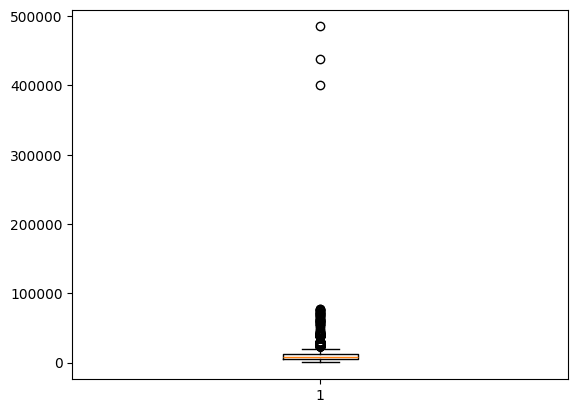

In [169]:
# vendo como o boxplot ficou depois de ajustar esses outliers que estavam acima do limite superior de 60 mil
plt.boxplot(dados['SALARIO'])

Vemos que esses pontinhos estão fora da caixinha mas dentro do nosso limite superior, onde entendemos o contexto e verificamos que fazem sentido.

Lembre-se sempre de que a abordagem para lidar com os outliers deve ser escolhida com base na natureza dos dados, nos objetivos da análise e no contexto específico do problema. Não há uma solução única que seja adequada para todos os casos e é importante avaliar as diferentes opções com cuidado.

### Intervalo de Confiança e Distribuição Amostral

> **População vs amostra: I**magine que você quer saber se a sopa está boa. Você não precisa tomar a panela inteira — basta uma colherada. A **panela inteira** é a população; a **colherada** é a amostra.

- População seria todos os funcionários, amostra seria os 4721 funcionarios selecionados que responderam qual é o salário deles.
- Nunca conseguimos medir a **população inteira** (custo, tempo, impossibilidade). Então usamos a amostra para **estimar** a realidade. Todo o restante desta aula trata de quão boa é essa estimativa.

> Média amostral: É como calcular a nota média da sua turma para estimar o desempenho médio de todos os alunos da escola. Um número só, simples e direto.

- A média amostral é uma **estimativa pontual,** um único número. O problema é que ela nunca vai acertar exatamente a média real. Por isso precisamos do erro padrão e do intervalo de confiança para medir essa imprecisão

> Desvio Padrão: Imagine dois times de basquete com média de altura de 1,90m. Um time tem todos os jogadores entre 1,88m e 1,92m (DP pequeno). O outro tem jogadores de 1,60m a 2,20m (DP grande). A média é igual, mas a *dispersão* é completamente diferente.

Mede o quanto os salários *individuais* variam entre si. Um valor alto indica que há muita diferença entre os funcionários.

> Erro padrão: A precisão da nossa estimativa da média. Se você pergunta a 5 pessoas qual a temperatura lá fora, as respostas vão variar bastante. Se você pergunta a 500 pessoas, a *média das respostas* vai ser muito mais estável e confiável. O erro padrão mede exatamente essa estabilidade.

Atenção: o EP e o DP medem coisas diferentes. O DP mede a **variação dos salários individuais**. O EP mede a **variação da média amostral** — o quanto ela pode "errar" a média verdadeira.

> Distribuição amostral: O comportamento das médias quando repetimos a amostragem

Imagine repetir a pesquisa 1.000 vezes, cada vez com um grupo diferente de 4.271 funcionários. Cada grupo daria uma média ligeiramente diferente. Se você plotasse todas essas médias num gráfico, elas formariam uma curva em forma de sino — isso é a distribuição amostral.

Este é o Teorema Central do Limite: independente da distribuição dos salários individuais, a distribuição das **médias amostrais** tende a uma curva normal quando n é grande o suficiente. É esse comportamento previsível que torna o IC possível.

> **Intervalo de confiança (IC) - A faixa onde acreditamos estar a média verdadeira**

Quando um meteorologista diz "temperatura entre 22°C e 28°C amanhã", ele não está dando um número exato — está dando uma *faixa de confiança*. O IC funciona da mesma forma: em vez de um ponto, damos um intervalo honesto.

O IC de 95% **não** significa "95% de chance de a média estar aqui". Significa: se repetíssemos o estudo 100 vezes, **95 dos 100 intervalos** gerados conteriam a verdadeira média. É uma garantia sobre o método, não sobre este intervalo específico.

- Nivel de confiança: Quer ter **99% de certeza** de que a chuva vai cair dentro da sua previsão? O meteorologista precisa ampliar o intervalo: "entre 10°C e 40°C". Quer um intervalo menor? Aceite mais risco de errar. Não dá para ter intervalo pequeno e confiança alta ao mesmo tempo. O nível de 95% é o padrão da ciência por conveniência histórica. Em medicina ou engenharia de segurança, usa-se 99%. Em pesquisas exploratórias, 90% pode ser suficiente. A escolha depende do **custo de errar** no seu contexto.

In [170]:
salarios = dados['SALARIO'] 
media_amostral = np.mean(salarios) # 9904
desvio_amostral = np.std(salarios) # 8306
nivel_confianca = 0.95 # 95% de confiança
tamanho_amostra = len(salarios) # 4271
erro_padrao = stats.sem(salarios) # 127
intervalo_confianca = stats.t.interval(nivel_confianca, tamanho_amostra-1, loc=media_amostral, scale=erro_padrao)

print(intervalo_confianca) # output (9655.186295869078, 10153.593923757535)

(np.float64(9816.284832630186), np.float64(10678.579172094494))


### Featuring Engineering: criando novas variáveis para facilitar a análise

Engenharia de recursos é o processo de criar novas variáveis a partir dos dados existentes para melhorar a análise e a modelagem.

In [171]:
# Criamos a coluna "NOVO_NIVEL":
# Criamos uma função chamada preencher_nivel que atribui o valor "Pessoa Gestora" se a coluna "GESTOR" for igual a 1; caso contrário, mantém o valor da coluna "NIVEL". Adicionamos essa nova coluna ao nosso DataFrame para diferenciar claramente entre gestores e outros níveis.

def preencher_nivel(gestor, nivel):
	if gestor == 1:
		return "Pessoa Gestora"
	else:
		return nivel
		
dados['NOVO NIVEL'] = dados.apply(lambda x: preencher_nivel(x['GESTOR?'], x['NIVEL']), axis=1)
dados['NOVO NIVEL']
dados['NOVO NIVEL'].value_counts()

NOVO NIVEL
Pleno             1060
Júnior            1023
Sênior             898
Pessoa Gestora     713
Name: count, dtype: int64

In [172]:
# Conversão de Variáveis Categóricas:
# Utilizamos pd.get_dummies para transformar a coluna "NIVEL" em variáveis dummy. Isso é útil para modelos de machine learning que requerem dados numéricos.

dados = pd.get_dummies(dados, columns=['NIVEL'])

In [173]:
# Criação da Coluna "GERAÇÃO":
# Desenvolvemos uma função chamada determinar_geracao para categorizar os indivíduos em diferentes gerações (Geração X, Millennial, Geração Z) com base na idade. Adicionamos essa nova coluna ao DataFrame, permitindo análises segmentadas por faixa etária.

def determinar_geracao(idade):
	if 39 < idade <= 58:
		return 'Geração X'
	elif 29 < idade <= 39:
		return 'Millenial'
	elif 13 < idade <= 29:
		return 'Geração Z'
	else:
		return 'Outra Geração'
		
dados['GERACAO'] = dados['IDADE'].apply(determinar_geracao)
dados['GERACAO'].value_counts()

GERACAO
Geração Z    1999
Millenial    1761
Geração X     511
Name: count, dtype: int64

In [174]:
# Identificação de Intenção de Mudança de Emprego:
# Criamos duas novas colunas, "EM_BUSCA" e "ABERTO_OPORTUNIDADES", a partir das respostas à pergunta sobre a intenção de mudar de emprego nos próximos 6 meses. Utilizamos funções de string para identificar se os respondentes estão "em busca" ou "abertos" a novas oportunidades, facilitando a análise do mercado de trabalho.
dados2.head()

dados = dados.merge(dados2, on='ID', how='left')

dados['Você pretende mudar de emprego nos próximos 6 meses?'].value_counts()

dados['EM_BUSCA'] = dados['Você pretende mudar de emprego nos próximos 6 meses?'].str.contains('em busca', case=False)
dados['EM_BUSCA'].value_counts()

dados['ABERTO_OPORTUNIDADES'] = dados['Você pretende mudar de emprego nos próximos 6 meses?'].str.contains('aberto', case=False)
dados['ABERTO_OPORTUNIDADES'].value_counts()

ABERTO_OPORTUNIDADES
False    2919
True     1354
Name: count, dtype: int64

In [175]:
# crie uma nova coluna de Etnia - brancas, não branca e outras

def categoria_etnia(etnia):
	if etnia == 'Branca':
		return 'Branca'
	elif etnia in ['Parda', 'Preta', 'Amarela', 'Indigena']:
		return 'Não Branca'
	else:
		return 'Outros'
		
dados['ETNIA'] = dados['COR/RACA/ETNIA'].apply(categoria_etnia)

### Correlação, diferentes funções para dados discretos e contínuos

- A correlação positiva ocorre quando duas variáveis aumentam juntas. Por exemplo, quanto mais um aluno estuda, maior é seu desempenho acadêmico.
- Já a correlação negativa acontecia quando uma variável aumenta enquanto a outra diminui. Por exemplo, quanto mais tempo um aluno passa assistindo TV, menor é seu desempenho acadêmico.

A função de correlação mais usada é a de **Pearson**, que varia de -1 a 1. Um valor próximo de 1 indica uma forte correlação positiva, próximo de -1 indica uma forte correlação negativa, e próximo de 0 indica que não há uma relação linear.

Por exemplo, ao calcular a correlação entre horas de estudo e desempenho acadêmico, um coeficiente de 0.8 indica uma correlação positiva forte.

No nosso caso, calculamos a correlação entre idade e salário usando a função corr do pandas. Obtivemos um valor de 0.29, indicando uma correlação positiva, mas não muito forte.

**Entender a correlação ajuda a evitar suposições.**

- Por exemplo, esperávamos que a idade fosse um fator importante para o aumento salarial, mas nossos dados mostram que, apesar de ter uma relação, não é tão forte. Para identificar correlações em tabelas com muitas colunas de valores contínuos, utilizamos mapas de calor.

In [178]:
correlacao_continua = dados['IDADE'].corr(dados['SALARIO']) 
print(correlacao_continua)

0.1764599705455863


**Se a idade não é um fator forte, então qual será o fator mais importante para se obter um aumento salarial?**

Quando temos uma tabela com muitas colunas de valores continuos, podemos aplicar um mapa de calor. Um exemplo de mapa de calor permite visualizar rapidamente a correlação entre variáveis contínuas, com cores indicando a força da correlação.

In [179]:
def cramer_coeficiente(coluna1, coluna2):
	tabela_cruzada = np.array(pd.crosstab(coluna1, coluna2))
	chi2 = chi2_contingency(tabela_cruzada)[0]
	soma = np.sum(tabela_cruzada)
	mini = min(tabela_cruzada.shape)-1
	cramer = np.sqrt(chi2/(soma * mini))
	return cramer
	
cramer_coeficiente(dados['COR/RACA/ETNIA'], dados['NIVEL DE ENSINO'])

cramer_coeficiente(dados['GENERO'], dados['NIVEL DE ENSINO'])

	
tabela_cruzada = pd.crosstab(dados['COR/RACA/ETNIA'], dados['NIVEL DE ENSINO'])
tabela_cruzada

print(np.array(tabela_cruzada))

[[  7  15  50  14   2   0  40]
 [127 365 999 355  65   8 827]
 [  0   2   4   2   0   0   3]
 [  0   0   6   3   1   0   7]
 [ 50 178 333 113  33   3 344]
 [  1   2  14   1   0   1   7]
 [  6  51 104  33   9   0  88]]
